In [2]:
# Import kutubxonalar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - asosiy ML kutubxonasi
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Display sozlamalari
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Reproducibility - har safar bir xil natija
np.random.seed(42)

print("Setup complete")

Setup complete


In [3]:
# Featured data yuklash (kechagi feature engineering natijasi)
df = pd.read_csv('../data/processed/featured_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nUstunlar:")
for col in df.columns:
    print(f"  - {col}")

# Target taqsimoti (imbalanced ekanini eslatish)
print(f"\nTarget taqsimoti:")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"Default foizi: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

Dataset shape: (149717, 17)

Ustunlar:
  - SeriousDlqin2yrs
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents
  - income_missing_flag
  - total_delinquency
  - has_dependents
  - income_per_dependent
  - zero_income_flag
  - age_group

Target taqsimoti:
SeriousDlqin2yrs
0    139839
1      9878
Name: count, dtype: int64
Default foizi: 6.60%


In [4]:
# Features (X) va target (y) ajratish
# X - barcha ustunlar, target'dan tashqari
# y - target ustun

# age_group categorical - hozircha drop qilamiz, keyin encode qilamiz
X = df.drop(columns=['SeriousDlqin2yrs', 'age_group'])
y = df['SeriousDlqin2yrs']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures:")
for col in X.columns:
    print(f"  - {col}")

X shape: (149717, 15)
y shape: (149717,)

Features:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents
  - income_missing_flag
  - total_delinquency
  - has_dependents
  - income_per_dependent
  - zero_income_flag


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test shape:  X={X_test.shape}, y={y_test.shape}")

print(f"\nTrain set default rate: {y_train.mean()*100:.2f}%")
print(f"Test set default rate:  {y_test.mean()*100:.2f}%")
print(f"Original default rate:  {y.mean()*100:.2f}%")

Train shape: X=(119773, 15), y=(119773,)
Test shape:  X=(29944, 15), y=(29944,)

Train set default rate: 6.60%
Test set default rate:  6.60%
Original default rate:  6.60%


In [6]:
# Feature Scaling - StandardScaler

# 1. Scaler yaratish
scaler = StandardScaler()

# 2. Train data'ga fit (statistikani o'rganish) va transform
X_train_scaled = scaler.fit_transform(X_train)

# 3. Test data'ni transform (train'ning statistikasi bilan)
X_test_scaled = scaler.transform(X_test)

# Yangi turlarni tekshirish
print(f"X_train_scaled type: {type(X_train_scaled).__name__}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

# DataFrame'ga qaytarish (column nomlari uchun)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Tekshirish - har feature mean ~0, std ~1
print("\nScaled features statistika:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(2))

X_train_scaled type: ndarray
X_train_scaled shape: (119773, 15)

Scaled features statistika:
      RevolvingUtilizationOfUnsecuredLines  age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
mean                                   0.0  0.0                                   0.0       -0.0            0.0                             -0.0                     -0.0   
std                                    1.0  1.0                                   1.0        1.0            1.0                              1.0                      1.0   

      NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents  income_missing_flag  total_delinquency  has_dependents  income_per_dependent  zero_income_flag  
mean                           0.0                                  -0.0                 0.0                 -0.0               -0.0             0.0                   0.0               0.0  
std  

In [7]:
# Logistic Regression train

# 1. Model yaratish (default parametrlar)
model = LogisticRegression(random_state=42, max_iter=1000)

# 2. Modelni train data'da o'qitish
model.fit(X_train_scaled, y_train)

# 3. Test set'da bashorat qilish
y_pred = model.predict(X_test_scaled)              # 0 yoki 1
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]   # ehtimol (0-1)

print("Logistic Regression train tugadi")
print(f"\nBashorat namunalari (birinchi 10):")
print(f"  y_pred:       {y_pred[:10]}")
print(f"  y_pred_proba: {y_pred_proba[:10].round(3)}")
print(f"  y_test:       {y_test.values[:10]}")

Logistic Regression train tugadi

Bashorat namunalari (birinchi 10):
  y_pred:       [0 0 0 0 0 0 0 0 0 0]
  y_pred_proba: [0.01  0.068 0.273 0.093 0.109 0.095 0.025 0.016 0.012 0.031]
  y_test:       [0 0 0 0 0 0 0 0 0 0]


In [9]:
# Metrikalarni hisoblash

print("=" * 50)
print("Logistic Regression - Baseline Results")
print("=" * 50)

# 1. Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy:  {acc*100:.2f}%")

# 2. Precision - "default" deganlarning necha foizi haqiqatan default
prec = precision_score(y_test, y_pred)
print(f"Precision: {prec*100:.2f}%")

# 3. Recall - haqiqiy defaultchilarning necha foizini topdik
rec = recall_score(y_test, y_pred)
print(f"Recall:    {rec*100:.2f}%")

# 4. F1 - Precision va Recall balansi
f1 = f1_score(y_test, y_pred)
print(f"F1-score:  {f1*100:.2f}%")

# 5. ROC-AUC - umumiy model sifati (threshold'dan mustaqil)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC:   {auc:.4f}")

# Naive baseline bilan taqqoslash
print("\n" + "=" * 50)
print("Naive baseline (har kim yaxshi deb taxmin)")
print("=" * 50)
naive_pred = np.zeros(len(y_test))
naive_acc = accuracy_score(y_test, naive_pred)
print(f"Naive Accuracy: {naive_acc*100:.2f}%")
print(f"Naive Recall:   0.00% (hech bir defaultchini topmaydi)")

Logistic Regression - Baseline Results

Accuracy:  93.82%
Precision: 62.50%
Recall:    15.94%
F1-score:  25.40%
ROC-AUC:   0.8474

Naive baseline (har kim yaxshi deb taxmin)
Naive Accuracy: 93.40%
Naive Recall:   0.00% (hech bir defaultchini topmaydi)


Confusion Matrix:
                Bashorat
              0          1
Haqiqat 0  [27779]  [  189]   ← Yaxshi mijozlar
        1  [ 1661]  [  315]   ← Defaultchilar

Tushuntirish:
  TN (to'g'ri yaxshi):      27779
  FP (yaxshi → default):      189  (false alarm)
  FN (default → yaxshi):     1661  (DANGER - kredit beriladi!)
  TP (to'g'ri default):       315


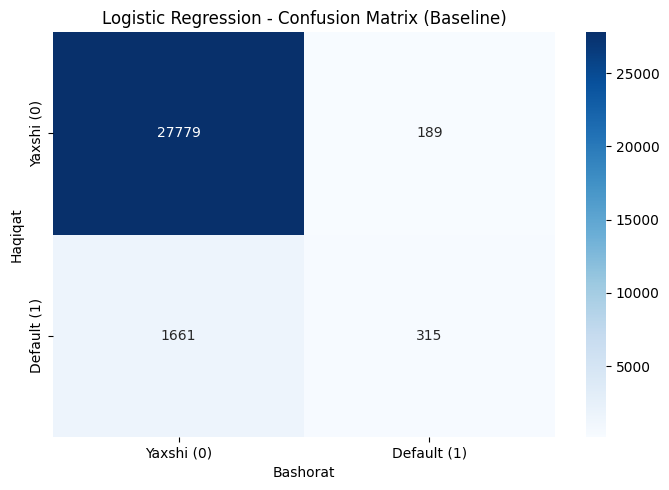

In [10]:
# Confusion Matrix - vizual
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(f"                Bashorat")
print(f"              0          1")
print(f"Haqiqat 0  [{cm[0,0]:5d}]  [{cm[0,1]:5d}]   ← Yaxshi mijozlar")
print(f"        1  [{cm[1,0]:5d}]  [{cm[1,1]:5d}]   ← Defaultchilar")

print(f"\nTushuntirish:")
print(f"  TN (to'g'ri yaxshi):      {cm[0,0]:5d}")
print(f"  FP (yaxshi → default):    {cm[0,1]:5d}  (false alarm)")
print(f"  FN (default → yaxshi):    {cm[1,0]:5d}  (DANGER - kredit beriladi!)")
print(f"  TP (to'g'ri default):     {cm[1,1]:5d}")

# Vizual chart
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yaxshi (0)', 'Default (1)'],
            yticklabels=['Yaxshi (0)', 'Default (1)'])
plt.xlabel('Bashorat')
plt.ylabel('Haqiqat')
plt.title('Logistic Regression - Confusion Matrix (Baseline)')
plt.tight_layout()
plt.show()

In [13]:
# Confusion Matrix - faqat raqamlar
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix - raw natija:")
print(cm)

Confusion Matrix - raw natija:
[[27779   189]
 [ 1661   315]]


In [17]:
# Logistic Regression - balanced version

model_balanced = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced'    # <-- yagona o'zgarish
)

model_balanced.fit(X_train_scaled, y_train)

# Bashorat
y_pred_bal = model_balanced.predict(X_test_scaled)
y_pred_proba_bal = model_balanced.predict_proba(X_test_scaled)[:, 1]

# Metrikalar
print("=" * 50)
print("Logistic Regression - BALANCED")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_bal)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_bal)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_bal)*100:.2f}%")
print(f"F1-score:  {f1_score(y_test, y_pred_bal)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_bal):.4f}")

# Baseline bilan taqqoslash
print("\n" + "=" * 50)
print("Baseline bilan taqqoslash")
print("=" * 50)
print(f"{'Metrik':<12} {'Baseline':<12} {'Balanced':<12} {'Farq':<12}")
print("-" * 48)
print(f"{'Accuracy':<12} {93.82:<12.2f} {accuracy_score(y_test, y_pred_bal)*100:<12.2f}")
print(f"{'Precision':<12} {62.50:<12.2f} {precision_score(y_test, y_pred_bal)*100:<12.2f}")
print(f"{'Recall':<12} {15.94:<12.2f} {recall_score(y_test, y_pred_bal)*100:<12.2f}")
print(f"{'F1':<12} {25.40:<12.2f} {f1_score(y_test, y_pred_bal)*100:<12.2f}")
print(f"{'ROC-AUC':<12} {0.8474:<12.4f} {roc_auc_score(y_test, y_pred_proba_bal):<12.4f}")

Logistic Regression - BALANCED
Accuracy:  80.13%
Precision: 21.13%
Recall:    73.58%
F1-score:  32.83%
ROC-AUC:   0.8541

Baseline bilan taqqoslash
Metrik       Baseline     Balanced     Farq        
------------------------------------------------
Accuracy     93.82        80.13       
Precision    62.50        21.13       
Recall       15.94        73.58       
F1           25.40        32.83       
ROC-AUC      0.8474       0.8541      


In [18]:
# LightGBM o'rnatilganmi tekshirish
try:
    import lightgbm as lgb
    print(f"LightGBM versiya: {lgb.__version__}")
except ImportError:
    print("LightGBM o'rnatilmagan!")
    print("Terminal'da yoz: pip install lightgbm")

LightGBM versiya: 4.6.0


In [19]:
# LightGBM - birinchi model (default parametrlar)

import lightgbm as lgb

# Model yaratish
model_lgb = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,       # 100 ta tree
    verbose=-1              # log xabarlarini yashirish
)

# Train
model_lgb.fit(X_train_scaled, y_train)

# Bashorat
y_pred_lgb = model_lgb.predict(X_test_scaled)
y_pred_proba_lgb = model_lgb.predict_proba(X_test_scaled)[:, 1]

# Metrikalar
print("=" * 50)
print("LightGBM - DEFAULT")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgb)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_lgb)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_lgb)*100:.2f}%")
print(f"F1-score:  {f1_score(y_test, y_pred_lgb)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lgb):.4f}")

LightGBM - DEFAULT
Accuracy:  93.80%
Precision: 60.35%
Recall:    17.56%
F1-score:  27.21%
ROC-AUC:   0.8630


In [20]:
# LightGBM - balanced version

model_lgb_balanced = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',    # <-- yagona o'zgarish
    verbose=-1
)

model_lgb_balanced.fit(X_train_scaled, y_train)

y_pred_lgb_bal = model_lgb_balanced.predict(X_test_scaled)
y_pred_proba_lgb_bal = model_lgb_balanced.predict_proba(X_test_scaled)[:, 1]

# Metrikalar
print("=" * 50)
print("LightGBM - BALANCED")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgb_bal)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_lgb_bal)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_lgb_bal)*100:.2f}%")
print(f"F1-score:  {f1_score(y_test, y_pred_lgb_bal)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lgb_bal):.4f}")

# Barcha modellar taqqoslash
print("\n" + "=" * 70)
print("BARCHA MODELLAR TAQQOSLASH")
print("=" * 70)
print(f"{'Metrik':<12} {'LR Base':<12} {'LR Bal':<12} {'LGB Base':<12} {'LGB Bal':<12}")
print("-" * 70)
print(f"{'Accuracy':<12} {93.82:<12.2f} {80.13:<12.2f} {93.80:<12.2f} {accuracy_score(y_test, y_pred_lgb_bal)*100:<12.2f}")
print(f"{'Precision':<12} {62.50:<12.2f} {21.13:<12.2f} {60.35:<12.2f} {precision_score(y_test, y_pred_lgb_bal)*100:<12.2f}")
print(f"{'Recall':<12} {15.94:<12.2f} {73.58:<12.2f} {17.56:<12.2f} {recall_score(y_test, y_pred_lgb_bal)*100:<12.2f}")
print(f"{'F1':<12} {25.40:<12.2f} {32.83:<12.2f} {27.21:<12.2f} {f1_score(y_test, y_pred_lgb_bal)*100:<12.2f}")
print(f"{'ROC-AUC':<12} {0.8474:<12.4f} {0.8541:<12.4f} {0.8630:<12.4f} {roc_auc_score(y_test, y_pred_proba_lgb_bal):<12.4f}")

LightGBM - BALANCED
Accuracy:  80.66%
Precision: 21.85%
Recall:    74.90%
F1-score:  33.82%
ROC-AUC:   0.8630

BARCHA MODELLAR TAQQOSLASH
Metrik       LR Base      LR Bal       LGB Base     LGB Bal     
----------------------------------------------------------------------
Accuracy     93.82        80.13        93.80        80.66       
Precision    62.50        21.13        60.35        21.85       
Recall       15.94        73.58        17.56        74.90       
F1           25.40        32.83        27.21        33.82       
ROC-AUC      0.8474       0.8541       0.8630       0.8630      


Feature Importance (LightGBM Balanced):
                             Feature  Importance
RevolvingUtilizationOfUnsecuredLines         489
                                 age         487
                           DebtRatio         450
                income_per_dependent         384
                       MonthlyIncome         339
     NumberOfOpenCreditLinesAndLoans         327
        NumberRealEstateLoansOrLines         174
                   total_delinquency         124
             NumberOfTimes90DaysLate          61
                  NumberOfDependents          59
NumberOfTime30-59DaysPastDueNotWorse          45
NumberOfTime60-89DaysPastDueNotWorse          43
                 income_missing_flag          17
                    zero_income_flag           1
                      has_dependents           0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8252\2279348098.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')


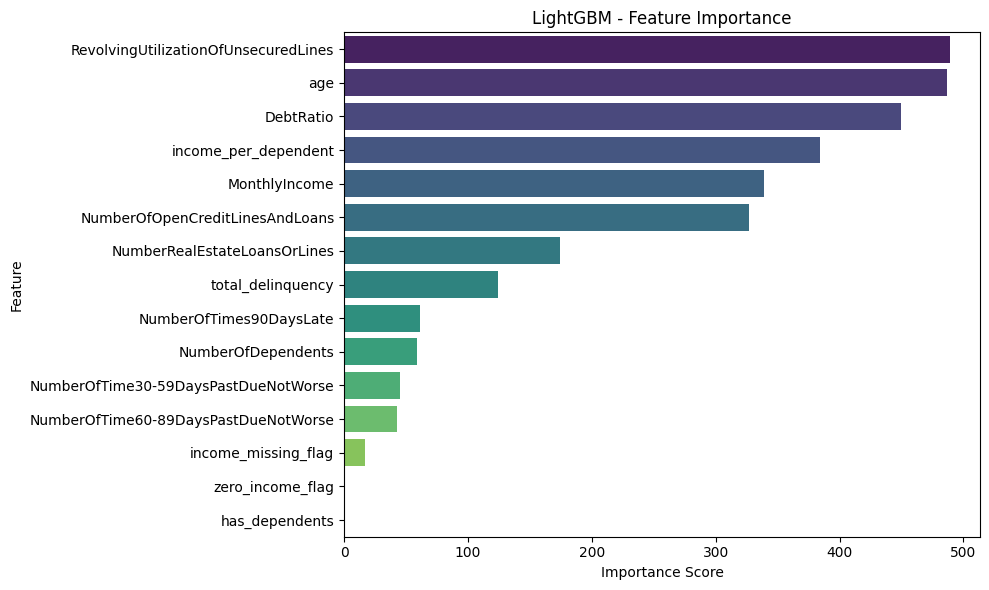

In [21]:
# Feature Importance - qaysi feature eng kuchli signal beradi?

# Importance qiymatlari (model ichida saqlanadi)
importances = model_lgb_balanced.feature_importances_

# DataFrame yaratish - sortlash uchun
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importance (LightGBM Balanced):")
print("=" * 50)
print(feature_imp_df.to_string(index=False))

# Vizual chart
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('LightGBM - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

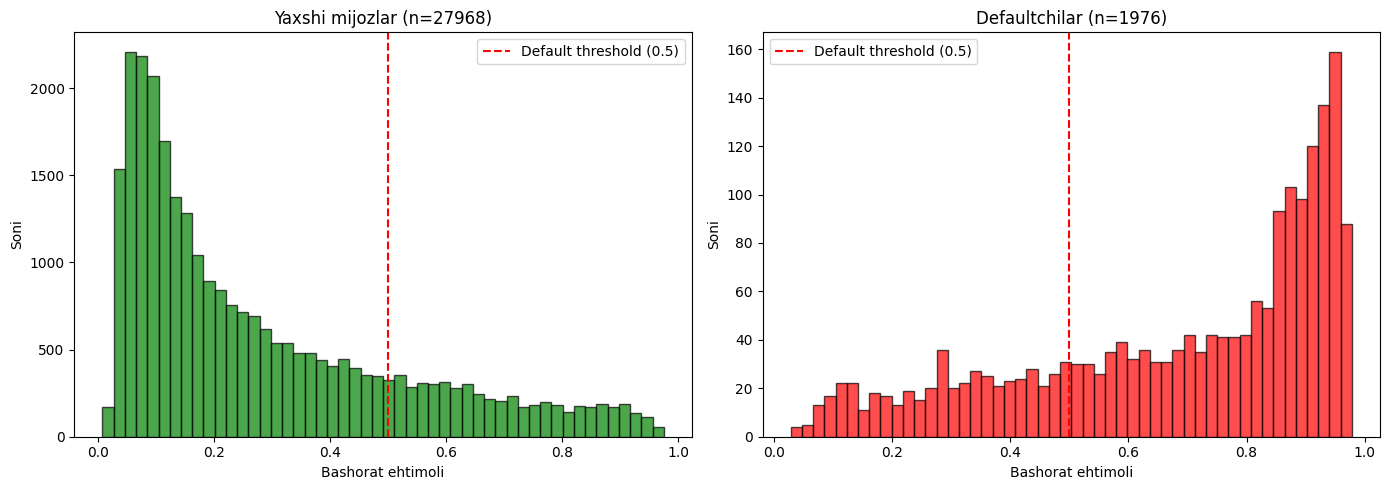

In [22]:
# Ehtimollar taqsimoti
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yaxshi mijozlarning ehtimollari (haqiqatan 0)
good_proba = y_pred_proba_lgb_bal[y_test == 0]
# Defaultchilarning ehtimollari (haqiqatan 1)
default_proba = y_pred_proba_lgb_bal[y_test == 1]

# Chart 1: Yaxshi mijozlar
axes[0].hist(good_proba, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
axes[0].set_title(f'Yaxshi mijozlar (n={len(good_proba)})')
axes[0].set_xlabel('Bashorat ehtimoli')
axes[0].set_ylabel('Soni')
axes[0].legend()

# Chart 2: Defaultchilar
axes[1].hist(default_proba, bins=50, color='red', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
axes[1].set_title(f'Defaultchilar (n={len(default_proba)})')
axes[1].set_xlabel('Bashorat ehtimoli')
axes[1].set_ylabel('Soni')
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Turli threshold'larni sinab ko'rish

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for t in thresholds:
    # Threshold bo'yicha bashorat
    y_pred_t = (y_pred_proba_lgb_bal >= t).astype(int)
    
    # Metrikalar
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    print(f"{t:<12} {prec*100:<12.2f} {rec*100:<12.2f} {f1*100:<12.2f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.2          12.00        93.47        21.26       
0.3          15.01        87.80        25.64       
0.4          18.15        81.68        29.70       
0.5          21.85        74.90        33.82       
0.6          26.29        66.50        37.68       
0.7          32.68        57.54        41.69       


Eng yaxshi F1 threshold: 0.80
Eng yaxshi F1 qiymati: 43.33%
  Precision: 40.60%
  Recall: 46.46%


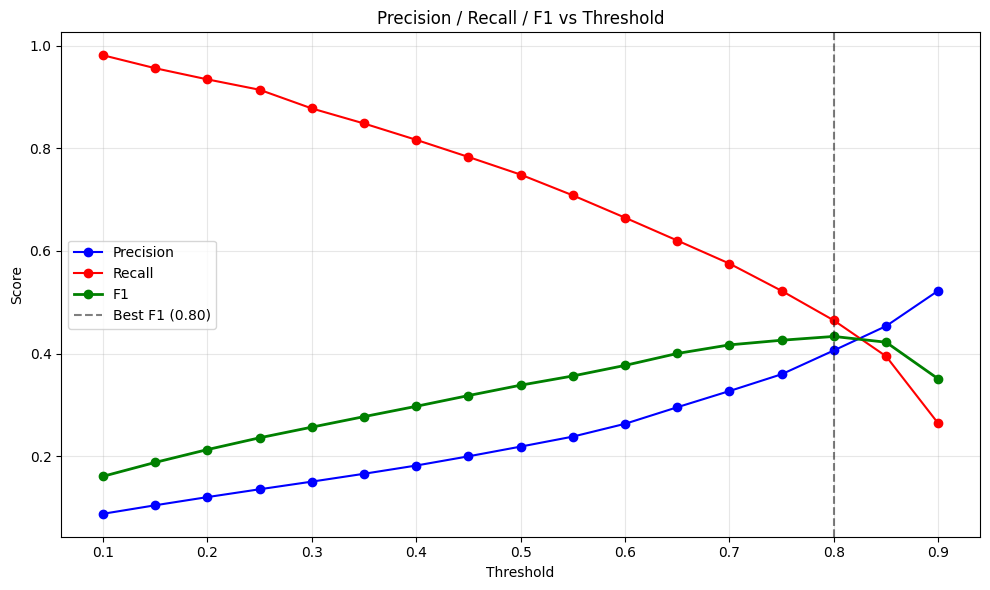

In [24]:
import numpy as np

# Keng diapazon - 0.1 dan 0.9 gacha
thresholds = np.arange(0.1, 0.95, 0.05)

results = []
for t in thresholds:
    y_pred_t = (y_pred_proba_lgb_bal >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})

results_df = pd.DataFrame(results)

# Eng yuqori F1
best_idx = results_df['f1'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1']

print(f"Eng yaxshi F1 threshold: {best_threshold:.2f}")
print(f"Eng yaxshi F1 qiymati: {best_f1*100:.2f}%")
print(f"  Precision: {results_df.loc[best_idx, 'precision']*100:.2f}%")
print(f"  Recall: {results_df.loc[best_idx, 'recall']*100:.2f}%")

# Vizual - Precision/Recall/F1 vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['precision'], 'o-', label='Precision', color='blue')
plt.plot(results_df['threshold'], results_df['recall'], 'o-', label='Recall', color='red')
plt.plot(results_df['threshold'], results_df['f1'], 'o-', label='F1', color='green', linewidth=2)
plt.axvline(best_threshold, color='black', linestyle='--', alpha=0.5, label=f'Best F1 ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# XGBoost tekshirish
try:
    import xgboost as xgb
    print(f"XGBoost versiya: {xgb.__version__}")
except ImportError:
    print("XGBoost o'rnatilmagan!")
    print("Terminal'da yoz: pip install xgboost")

XGBoost versiya: 3.2.0


In [26]:
import xgboost as xgb

# scale_pos_weight hisoblash
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# XGBoost - balanced
model_xgb = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,   # imbalanced uchun
    eval_metric='logloss',               # baholash metrikasi
    verbosity=0                          # log'larni o'chirish
)

model_xgb.fit(X_train_scaled, y_train)

y_pred_xgb = model_xgb.predict(X_test_scaled)
y_pred_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

# Metrikalar
print("\n" + "=" * 50)
print("XGBoost - BALANCED")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

scale_pos_weight: 14.16

XGBoost - BALANCED
Accuracy:  82.50%
Precision: 22.62%
Recall:    68.22%
F1-score:  33.97%
ROC-AUC:   0.8436


In [27]:
# BARCHA MODELLAR - yakuniy taqqoslash

print("=" * 78)
print("BARCHA MODELLAR - YAKUNIY TAQQOSLASH")
print("=" * 78)
print(f"{'Metrik':<12} {'LR Base':<11} {'LR Bal':<11} {'LGB Base':<11} {'LGB Bal':<11} {'XGB Bal':<11}")
print("-" * 78)

print(f"{'Accuracy':<12} {93.82:<11.2f} {80.13:<11.2f} {93.80:<11.2f} {80.66:<11.2f} {accuracy_score(y_test, y_pred_xgb)*100:<11.2f}")
print(f"{'Precision':<12} {62.50:<11.2f} {21.13:<11.2f} {60.35:<11.2f} {21.85:<11.2f} {precision_score(y_test, y_pred_xgb)*100:<11.2f}")
print(f"{'Recall':<12} {15.94:<11.2f} {73.58:<11.2f} {17.56:<11.2f} {74.90:<11.2f} {recall_score(y_test, y_pred_xgb)*100:<11.2f}")
print(f"{'F1':<12} {25.40:<11.2f} {32.83:<11.2f} {27.21:<11.2f} {33.82:<11.2f} {f1_score(y_test, y_pred_xgb)*100:<11.2f}")
print(f"{'ROC-AUC':<12} {0.8474:<11.4f} {0.8541:<11.4f} {0.8630:<11.4f} {0.8630:<11.4f} {roc_auc_score(y_test, y_pred_proba_xgb):<11.4f}")

print("\n" + "=" * 78)
print("XULOSA")
print("=" * 78)
print("Eng yuqori ROC-AUC: LightGBM Balanced (0.8630)")
print("Eng yuqori Recall:  LightGBM Balanced (74.90%)")
print("Eng yuqori F1:      XGBoost Balanced (33.97%) - LGB bilan deyarli teng")

BARCHA MODELLAR - YAKUNIY TAQQOSLASH
Metrik       LR Base     LR Bal      LGB Base    LGB Bal     XGB Bal    
------------------------------------------------------------------------------
Accuracy     93.82       80.13       93.80       80.66       82.50      
Precision    62.50       21.13       60.35       21.85       22.62      
Recall       15.94       73.58       17.56       74.90       68.22      
F1           25.40       32.83       27.21       33.82       33.97      
ROC-AUC      0.8474      0.8541      0.8630      0.8630      0.8436     

XULOSA
Eng yuqori ROC-AUC: LightGBM Balanced (0.8630)
Eng yuqori Recall:  LightGBM Balanced (74.90%)
Eng yuqori F1:      XGBoost Balanced (33.97%) - LGB bilan deyarli teng


In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Eng yaxshi modelni cross-validate qilamiz: LightGBM Balanced
model_cv = lgb.LGBMClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced',
    verbose=-1
)

# Stratified 5-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation - ROC-AUC bo'yicha
# DIQQAT: butun X, y ishlatamiz (split emas), CV o'zi ajratadi
X_full = df.drop(columns=['SeriousDlqin2yrs', 'age_group'])
y_full = df['SeriousDlqin2yrs']

# Scaling - butun data uchun (CV ichida har fold alohida bo'lardi, lekin soddalik uchun)
X_full_scaled = scaler.fit_transform(X_full)

cv_scores = cross_val_score(
    model_cv, 
    X_full_scaled, 
    y_full, 
    cv=cv, 
    scoring='roc_auc'
)

print("=" * 50)
print("Stratified 5-Fold Cross-Validation (ROC-AUC)")
print("=" * 50)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nO'rtacha AUC:      {cv_scores.mean():.4f}")
print(f"Standart og'ish:   {cv_scores.std():.4f}")
print(f"\nDiapazon: {cv_scores.mean()-cv_scores.std():.4f} - {cv_scores.mean()+cv_scores.std():.4f}")

# Single split bilan taqqoslash
print(f"\nSingle split AUC edi: 0.8630")
print(f"CV o'rtacha AUC:      {cv_scores.mean():.4f}")

c:\Users\ASUS\Projectsme\credit-default-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Projectsme\credit-default-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Projectsme\credit-default-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Projectsme\credit-default-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stratified 5-Fold Cross-Validation (ROC-AUC)
  Fold 1: 0.8625
  Fold 2: 0.8597
  Fold 3: 0.8634
  Fold 4: 0.8650
  Fold 5: 0.8617

O'rtacha AUC:      0.8625
Standart og'ish:   0.0017

Diapazon: 0.8607 - 0.8642

Single split AUC edi: 0.8630
CV o'rtacha AUC:      0.8625


c:\Users\ASUS\Projectsme\credit-default-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
